In [ ]:
import pandas as pd
import glob
import os

# Set path
folder_path = '/Users/liangyin/sta220/spotify_weekly_top_song_all_info' 

# Get data
all_files = glob.glob(os.path.join(folder_path, "*.csv"))

all_files.sort()
global_file = [f for f in all_files if 'global.csv' in os.path.basename(f)]
other_files = [f for f in all_files if 'global.csv' not in os.path.basename(f)]
all_files = global_file + other_files 

li = []

for filename in all_files:
    df = pd.read_csv(filename, index_col=None, header=0)
    
    country_code = os.path.basename(filename).split('.')[0]
    df['country'] = country_code
    
    li.append(df[:50])

full_df = pd.concat(li, axis=0, ignore_index=True)

country_map = {
    'global': 'Global',
    'at': 'Austria',
    'br': 'Brazil',
    'id': 'Indonesia',
    'in': 'India',
    'it': 'Italy',
    'jp': 'Japan',
    'mx': 'Mexico',
    'tw': 'Taiwan',
    'us': 'United States'
}

# Add 'country_name' col
full_df['country_name'] = full_df['country'].map(country_map)
print(f"Read {len(all_files)} files")
print(full_df.head())

成功讀取 10 個檔案
   rank                                       track_artist  peak  prev  \
0     1                                    DtMF\nBad Bunny     1   1.0   
1     2  Stateside + Zara Larsson\nPinkPantheress, Zara...     2  11.0   
2     3                            Risk It All\nBruno Mars     3   NaN   
3     4                              End of Beginning\nDjo     1   3.0   
4     5                            Man I Need\nOlivia Dean     3   5.0   

   streak   streams                track_name                   artist_name  \
0      61  39131995                      DtMF                     Bad Bunny   
1       8  38913426  Stateside + Zara Larsson  PinkPantheress, Zara Larsson   
2       1  36569896               Risk It All                    Bruno Mars   
3     107  31777044          End of Beginning                           Djo   
4      28  31301570                Man I Need                   Olivia Dean   

   duration_ms explicit is_local release_date               artist_i

In [2]:
display(full_df)

,rank,track_artist,peak,prev,streak,streams,track_name,artist_name,duration_ms,explicit,is_local,release_date,artist_id,track_id,duration_sec,country,country_name
0,1,DtMF\nBad Bunny,1,1.0,61,39131995,DtMF,Bad Bunny,237117.0,True,False,2025-01-05,4q3ewBCX7sLwd24euuV69X,3sK8wGT43QFpWrvNQsrQya,237.0,global,Global
1,2,"Stateside + Zara Larsson\nPinkPantheress, Zara...",2,11.0,8,38913426,Stateside + Zara Larsson,"PinkPantheress, Zara Larsson",184761.0,False,False,2025-10-10,78rUTD7y6Cy67W1RVzYs7t,1DwscornXpj8fmOmYVlqZt,185.0,global,Global
2,3,Risk It All\nBruno Mars,3,NaN,1,36569896,Risk It All,Bruno Mars,204068.0,False,False,2026-02-27,0du5cEVh5yTK9QJze8zA0C,5y2ijHECwFYWqcAHKTZgzD,204.0,global,Global
3,4,End of Beginning\nDjo,1,3.0,107,31777044,End of Beginning,Djo,159245.0,False,False,2022-09-16,5p9HO3XC5P3BLxJs5Mtrhm,3qhlB30KknSejmIvZZLjOD,159.0,global,Global
4,5,Man I Need\nOlivia Dean,3,5.0,28,31301570,Man I Need,Olivia Dean,184000.0,False,False,2025-08-15,00x1fYSGhdqScXBRpSj3DW,1qbmS6ep2hbBRaEZFpn7BX,184.0,global,Global
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,46,VOY A LLeVARTE PA PR\nBad Bunny,7,19.0,4,3557882,VOY A LLeVARTE PA PR,Bad Bunny,156364.0,True,False,2025-01-05,4q3ewBCX7sLwd24euuV69X,59D4DOkspUbWyMmbAPQkxZ,156.0,us,United States
496,47,"Die With A Smile\nLady Gaga, Bruno Mars",1,36.0,80,3543774,Die With A Smile,"Lady Gaga, Bruno Mars",251667.0,False,False,2024-08-16,1HY2Jd0NmPuamShAr6KMms,2plbrEY59IikOBgBGLjaoe,252.0,us,United States
497,48,No Pole\nDon Toliver,25,47.0,71,3541262,No Pole,Don Toliver,187613.0,True,False,2023-02-28,4Gso3d4CscCijv0lmajZWs,0eaVIYo2zeOaGJeqZ5TwYz,188.0,us,United States
498,49,House Money\nBaby Keem,49,NaN,1,3516915,House Money,Baby Keem,195612.0,True,False,2026-02-20,5SXuuuRpukkTvsLuUknva1,5Th1SPySWgYlkXXC6wLMwL,196.0,us,United States


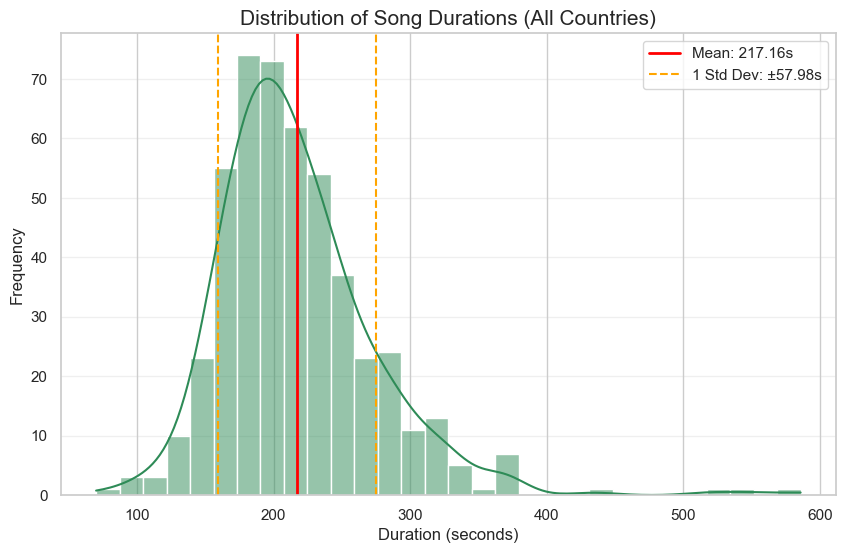

In [ ]:
import pandas as pd
import glob
import os
import matplotlib.pyplot as plt
import seaborn as sns

# Cal value
mean_val = full_df['duration_sec'].mean()
std_val = full_df['duration_sec'].std()

plt.figure(figsize=(10, 6))

# Plot
sns.histplot(full_df['duration_sec'], kde=True, color='seagreen', bins=30)

# Mean line
plt.axvline(mean_val, color='red', linestyle='-', linewidth=2, label=f'Mean: {mean_val:.2f}s')

# Std
plt.axvline(mean_val - std_val, color='orange', linestyle='--', linewidth=1.5, label=f'1 Std Dev: ±{std_val:.2f}s')
plt.axvline(mean_val + std_val, color='orange', linestyle='--', linewidth=1.5)


plt.title('Distribution of Song Durations (All Countries)', fontsize=15)
plt.xlabel('Duration (seconds)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.legend()
plt.grid(axis='y', alpha=0.3)

plt.show()

/var/folders/jh/dn7zw8d94b18kft5y56xg5rm0000gn/T/ipykernel_1819/1029481905.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=full_df, x='country_name', y='duration_sec', palette='Greens')


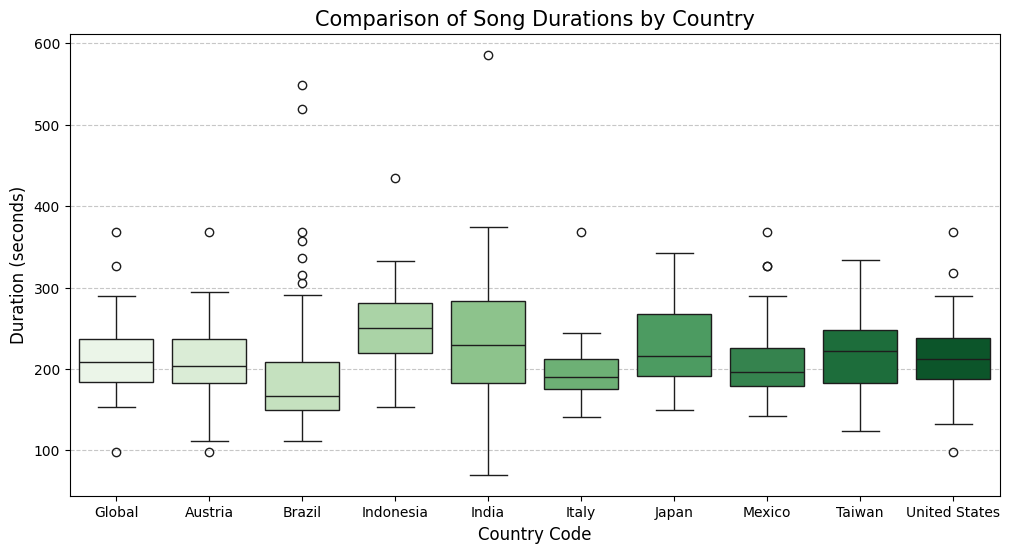

In [4]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=full_df, x='country_name', y='duration_sec', palette='Greens')

plt.title('Comparison of Song Durations by Country', fontsize=15)
plt.xlabel('Country Code', fontsize=12)
plt.ylabel('Duration (seconds)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

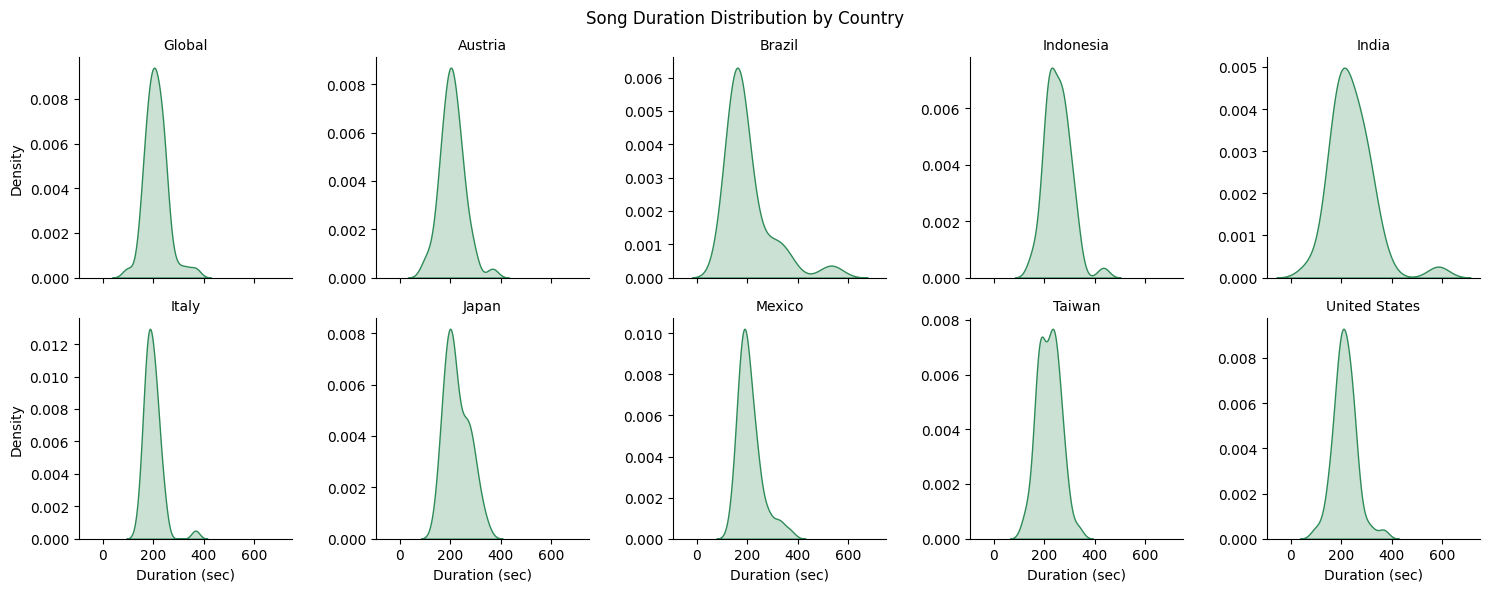

In [ ]:
# Subgroup plots
g = sns.FacetGrid(full_df, col="country_name", col_wrap=5, height=3, sharey=False)
g.map(sns.kdeplot, "duration_sec", fill=True, color="seagreen")

g.set_titles("{col_name}")
g.set_axis_labels("Duration (sec)", "Density")
plt.subplots_adjust(top=0.9)
g.fig.suptitle('Song Duration Distribution by Country')
plt.show()

/var/folders/jh/dn7zw8d94b18kft5y56xg5rm0000gn/T/ipykernel_1819/2298501476.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=plot_data, x='rank_bin', y='deviation_sec', palette=colors)


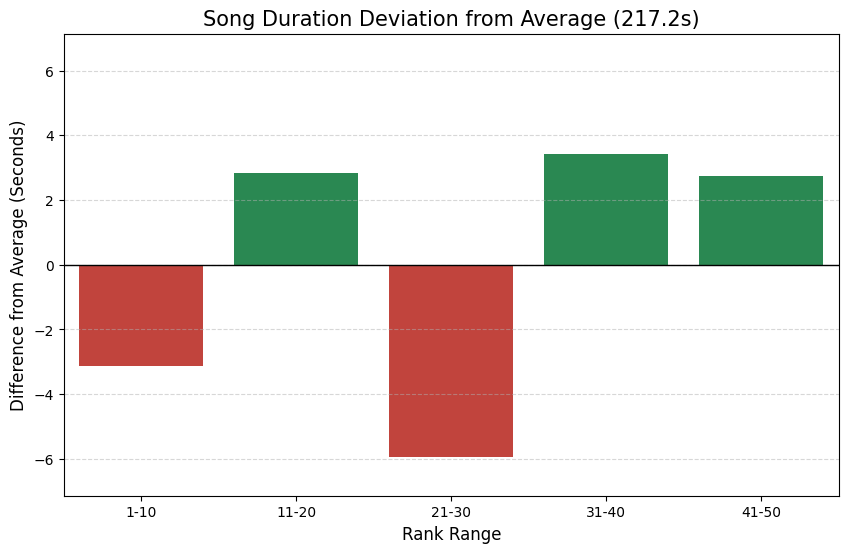

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

def plot_duration_deviation_by_bins(df):
    df = df.copy()
        
    bins = [0, 10, 20, 30, 40, 50]
    labels = ['1-10', '11-20', '21-30', '31-40', '41-50']
    df['rank_bin'] = pd.cut(df['rank'], bins=bins, labels=labels)
    
    grand_mean = df['duration_sec'].mean()
    bin_means = df.groupby('rank_bin')['duration_sec'].mean()
    deviation = bin_means - grand_mean
    
    plot_data = deviation.reset_index()
    plot_data.columns = ['rank_bin', 'deviation_sec']
    
    plt.figure(figsize=(10, 6))
    
    colors = ['#d73027' if x < 0 else '#1a9850' for x in plot_data['deviation_sec']]
    
    sns.barplot(data=plot_data, x='rank_bin', y='deviation_sec', palette=colors)
    
    plt.axhline(0, color='black', linewidth=1)
    
    plt.title(f'Song Duration Deviation from Average ({grand_mean:.1f}s)', fontsize=15)
    plt.xlabel('Rank Range', fontsize=12)
    plt.ylabel('Difference from Average (Seconds)', fontsize=12)
    
    limit = max(abs(plot_data['deviation_sec'])) * 1.2
    plt.ylim(-limit, limit)
    
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    plt.show()

plot_duration_deviation_by_bins(full_df)

/var/folders/jh/dn7zw8d94b18kft5y56xg5rm0000gn/T/ipykernel_1819/452101114.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=data, x='rank_bin', y='deviation_sec', palette=colors)
/var/folders/jh/dn7zw8d94b18kft5y56xg5rm0000gn/T/ipykernel_1819/452101114.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=data, x='rank_bin', y='deviation_sec', palette=colors)
/var/folders/jh/dn7zw8d94b18kft5y56xg5rm0000gn/T/ipykernel_1819/452101114.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=data, x='rank_bin', y='deviation_sec', pa

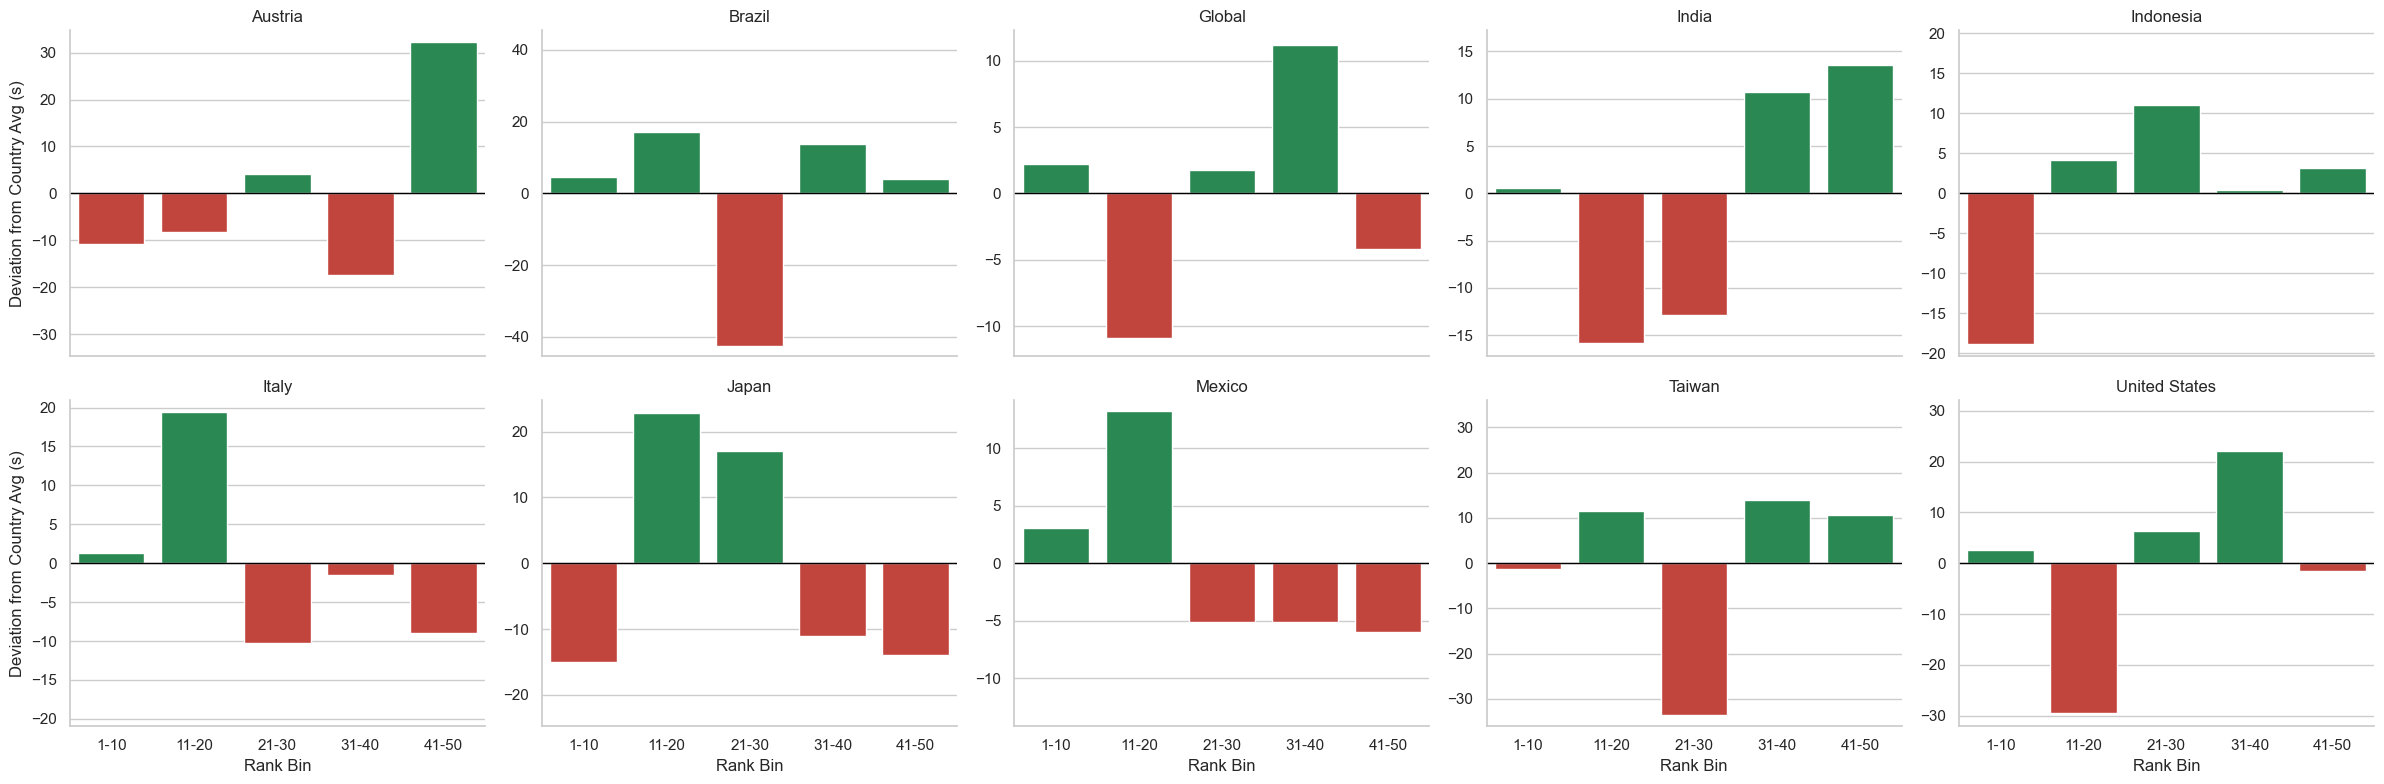

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

def plot_country_duration_deviation(df):
    df = df.copy()
    
    df['rank'] = df.groupby('country').cumcount() + 1
    
    bins = [0, 10, 20, 30, 40, 50]
    labels = ['1-10', '11-20', '21-30', '31-40', '41-50']
    df['rank_bin'] = pd.cut(df['rank'], bins=bins, labels=labels)
    
    df['country_mean'] = df.groupby('country')['duration_sec'].transform('mean')
    
    group_data = df.groupby(['country_name', 'rank_bin'])['duration_sec'].mean().reset_index()
    country_means = df.groupby('country_name')['duration_sec'].mean().reset_index().rename(columns={'duration_sec': 'c_mean'})
    
    plot_df = pd.merge(group_data, country_means, on='country_name')
    plot_df['deviation_sec'] = plot_df['duration_sec'] - plot_df['c_mean']

    sns.set_theme(style="whitegrid")
    g = sns.FacetGrid(plot_df, col="country_name", col_wrap=5, height=4, aspect=1.2, sharey=False)

    def draw_bars(data, **kwargs):
        colors = ['#d73027' if x < 0 else '#1a9850' for x in data['deviation_sec']]
        sns.barplot(data=data, x='rank_bin', y='deviation_sec', palette=colors)
        plt.axhline(0, color='black', linewidth=1) # 畫出 0 基準線

    g.map_dataframe(draw_bars)

    g.set_axis_labels("Rank Bin", "Deviation from Country Avg (s)")
    g.set_titles(col_template="{col_name}")
    
    for ax in g.axes:
        curr_ylim = max(abs(np.array(ax.get_ylim())))
        ax.set_ylim(-curr_ylim, curr_ylim)

    plt.tight_layout()
    plt.show()

plot_country_duration_deviation(full_df)

In [ ]:
import pandas as pd
from scipy import stats

def check_rank_correlation(df):
    df = df.copy()
    df = df.dropna(subset=['duration_sec'])
    
    results = []
    
    for country, group in df.groupby('country_name'):
        ranks = group['rank']
        durations = group['duration_sec']
        
        rho, p_val = stats.spearmanr(durations, ranks)
        
        results.append({
            'country': country,
            'spearman_rho': rho,
            'p_value': p_val,
            'is_significant': p_val < 0.05 
        })
        
    result_df = pd.DataFrame(results)
    return result_df

correlation_results = check_rank_correlation(full_df)
print(correlation_results)

         country  spearman_rho   p_value  is_significant
0        Austria      0.187176  0.193055           False
1         Brazil     -0.048313  0.744356           False
2         Global      0.076559  0.597195           False
3          India      0.014674  0.932309           False
4      Indonesia      0.128896  0.372335           False
5          Italy     -0.105455  0.466089           False
6          Japan     -0.063683  0.660400           False
7         Mexico      0.038810  0.789018           False
8         Taiwan      0.076048  0.603521           False
9  United States      0.196091  0.172318           False


Explicit

In [ ]:
def calculate_explicit_ratio(df):
    df = df.copy()
    if df['explicit'].dtype == 'object':
        df['explicit'] = df['explicit'].astype(str).str.lower() == 'true'
    
    df = df.dropna(subset=['explicit'])
    
    stats_df = df.groupby('country_name')['explicit'].agg(['sum', 'count', 'mean']).reset_index()
    
    stats_df.columns = ['country_name', 'explicit_count', 'total_valid_count', 'explicit_ratio']
    
    stats_df = stats_df.sort_values('explicit_ratio', ascending=False)
    stats_df['explicit_percentage'] = (stats_df['explicit_ratio'] * 100).round(2).astype(str) + '%'
    
    return stats_df[['country_name', 'explicit_count', 'total_valid_count', 'explicit_ratio', 'explicit_percentage']]

explicit_analysis = calculate_explicit_ratio(full_df)
print(explicit_analysis)

    country_name  explicit_count  total_valid_count  explicit_ratio  \
9  United States              16                 50            0.32   
2         Global              11                 50            0.22   
8         Taiwan               2                 50            0.04   
0        Austria               0                 50            0.00   
1         Brazil               0                 50            0.00   
3          India               0                 50            0.00   
5          Italy               0                 50            0.00   
4      Indonesia               0                 50            0.00   
7         Mexico               0                 50            0.00   
6          Japan               0                 50            0.00   

  explicit_percentage  
9               32.0%  
2               22.0%  
8                4.0%  
0                0.0%  
1                0.0%  
3                0.0%  
5                0.0%  
4                0.0%  
7 

In [ ]:
def calculate_is_local_ratio(df):
    df = df.copy()
    if df['is_local'].dtype == 'object':
        df['is_local'] = df['is_local'].astype(str).str.lower() == 'true'
    
    df = df.dropna(subset=['is_local'])
    
    stats_df = df.groupby('country_name')['is_local'].agg(['sum', 'count', 'mean']).reset_index()
    
    stats_df.columns = ['country_name', 'is_local_count', 'total_valid_count', 'is_local_ratio']
    
    stats_df = stats_df.sort_values('is_local_ratio', ascending=False)
    stats_df['is_local_percentage'] = (stats_df['is_local_ratio'] * 100).round(2).astype(str) + '%'
    
    return stats_df[['country_name', 'is_local_count', 'total_valid_count', 'is_local_ratio', 'is_local_percentage']]

is_local_analysis = calculate_is_local_ratio(full_df)
print(is_local_analysis)

    country_name  is_local_count  total_valid_count  is_local_ratio  \
0        Austria               0                 50             0.0   
1         Brazil               0                 50             0.0   
2         Global               0                 50             0.0   
3          India               0                 50             0.0   
4      Indonesia               0                 50             0.0   
5          Italy               0                 50             0.0   
6          Japan               0                 50             0.0   
7         Mexico               0                 50             0.0   
8         Taiwan               0                 50             0.0   
9  United States               0                 50             0.0   

  is_local_percentage  
0                0.0%  
1                0.0%  
2                0.0%  
3                0.0%  
4                0.0%  
5                0.0%  
6                0.0%  
7                0.0%  
8 

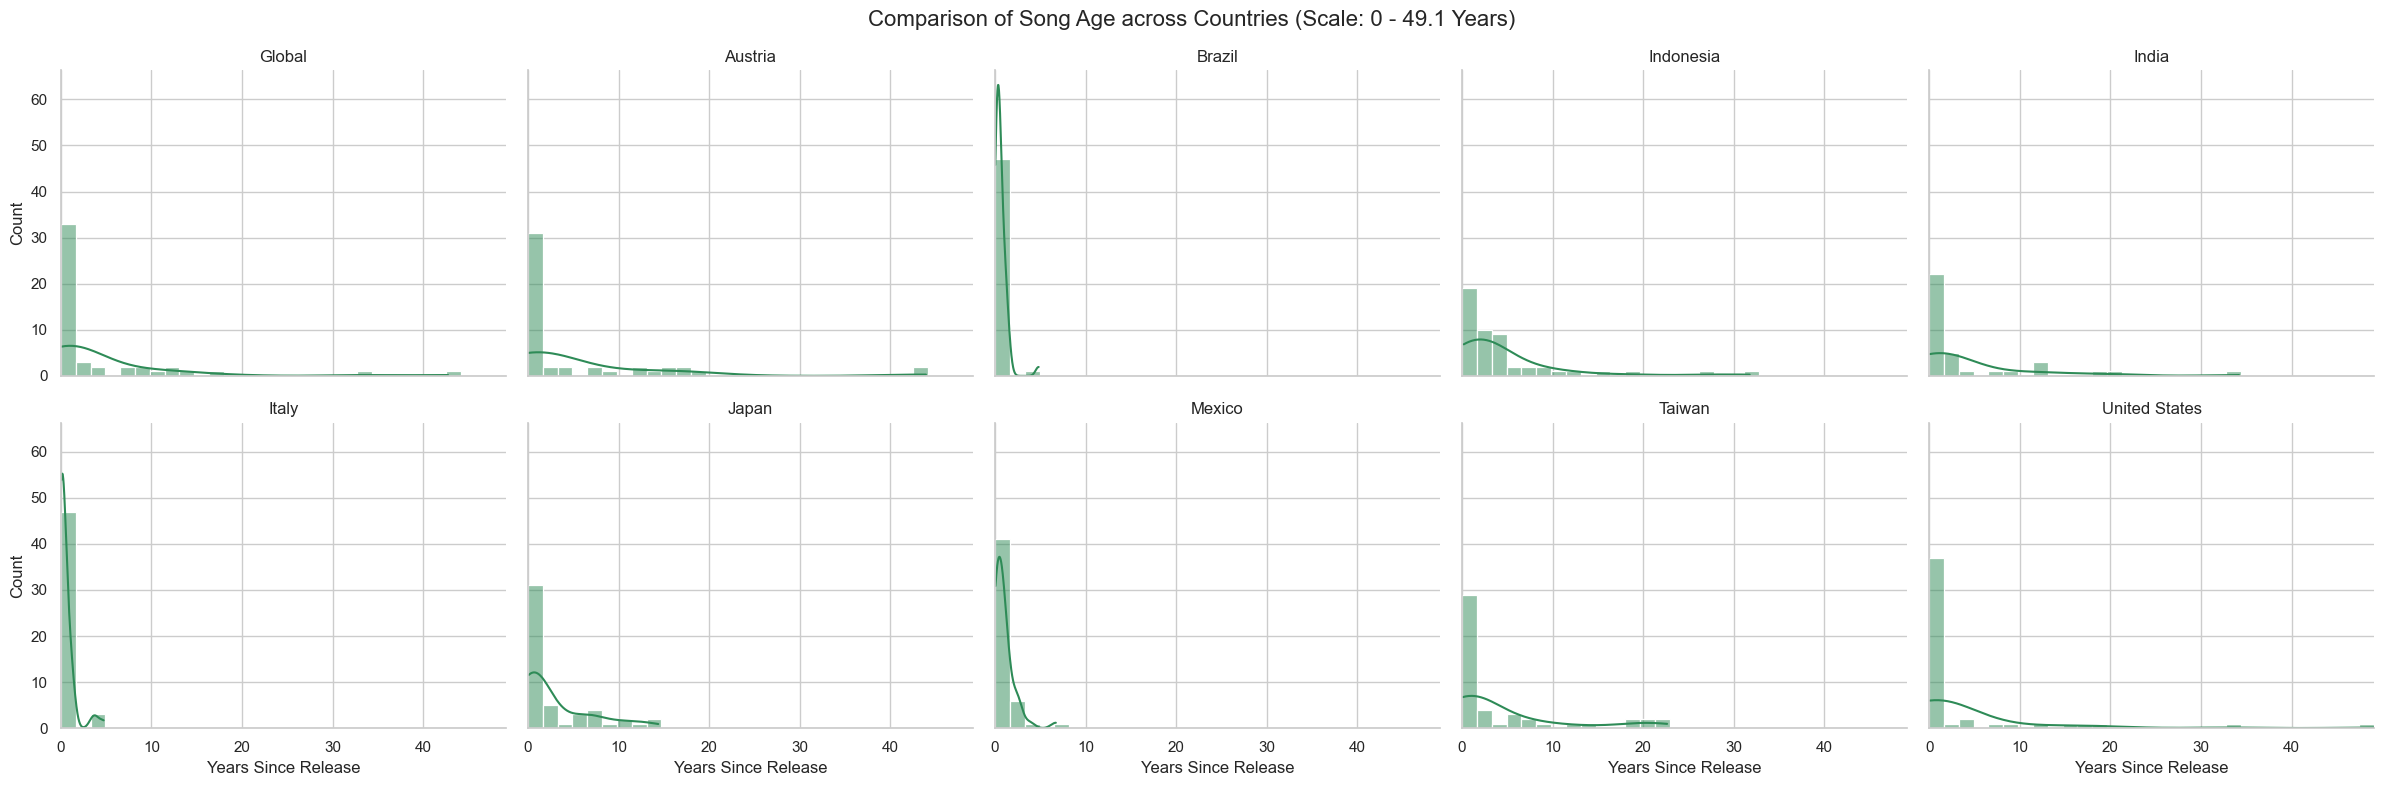

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from datetime import datetime
import numpy as np

def plot_release_age_distribution_fixed_scale(df):
    df = df.copy()
    
    df['release_date'] = pd.to_datetime(df['release_date'], errors='coerce')
    df = df.dropna(subset=['release_date'])
    
    today = pd.Timestamp(datetime.now())
    df['years_since_release'] = (today - df['release_date']).dt.days / 365.25

    x_min = 0
    x_max = df['years_since_release'].max()
    
    sns.set_theme(style="whitegrid")
    
    g = sns.FacetGrid(df, col="country_name", col_wrap=5, height=4, aspect=1.2, sharex=True)
    

    g.map(sns.histplot, "years_since_release", kde=True, color="seagreen", 
          bins=30, binrange=(x_min, x_max))
    
    g.set(xlim=(x_min, x_max))
    
    g.set_axis_labels("Years Since Release", "Count")
    g.set_titles(col_template="{col_name}")
    
    plt.subplots_adjust(top=0.9)
    g.fig.suptitle(f'Comparison of Song Age across Countries (Scale: 0 - {x_max:.1f} Years)', fontsize=16)
    
    plt.tight_layout()
    plt.show()

plot_release_age_distribution_fixed_scale(full_df)

In [ ]:
def find_classic_hits(df, threshold_years=40):
    df = df.copy()
    
    df['release_date'] = pd.to_datetime(df['release_date'], errors='coerce')
    
    df = df.dropna(subset=['release_date'])
    
    today = pd.Timestamp(datetime.now())
    df['years_since_release'] = (today - df['release_date']).dt.days / 365.25
    
    classics = df[df['years_since_release'] >= threshold_years].copy()
    
    result = classics[[
        'rank', 'country_name', 'track_name', 'artist_name', 'release_date', 'years_since_release'
    ]].sort_values('years_since_release', ascending=False)
    
    return result

classic_songs = find_classic_hits(full_df)

if classic_songs.empty:
    print(f"No old song")
else:
    print(f"Found {len(classic_songs)} old songs：")
    display(classic_songs)

共發現 4 筆超過 40 年的經典老歌資料：


,rank,country_name,track_name,artist_name,release_date,years_since_release
475,26,United States,Dreams - 2004 Remaster,Fleetwood Mac,1977-02-04,49.106092
91,42,Austria,Africa,TOTO,1982-04-08,43.934292
70,21,Austria,Every Breath You Take,The Police,1983-06-17,42.743326
26,27,Global,Every Breath You Take,The Police,1983-06-17,42.743326


In [ ]:
import pandas as pd

def get_top_artists_by_country(df, top_n=3):
    artist_counts = df.groupby(['country_name', 'artist_name']).size().reset_index(name='count')
    
    artist_counts = artist_counts.sort_values(['country_name', 'count'], ascending=[True, False])
    
    top_artists = artist_counts.groupby('country_name').head(top_n).copy()
    
    top_artists['rank'] = top_artists.groupby('country_name').cumcount() + 1
    
    return top_artists

top_3_artists_all = get_top_artists_by_country(full_df)
display(top_3_artists_all[['country_name', 'rank', 'artist_name', 'count']])

,country_name,rank,artist_name,count
2,Austria,1,Bad Bunny,5
39,Austria,2,sombr,4
9,Austria,3,Dominic Fike,2
41,Brazil,1,Bad Bunny,2
48,Brazil,2,Danilo e Davi,2
58,Brazil,3,Henrique & Juliano,2
89,Global,1,Bad Bunny,6
93,Global,2,Bruno Mars,5
120,Global,3,sombr,3
129,India,1,Anuv Jain,2


In [15]:
display(full_df)

,rank,track_artist,peak,prev,streak,streams,track_name,artist_name,duration_ms,explicit,is_local,release_date,artist_id,track_id,duration_sec,country,country_name
0,1,DtMF\nBad Bunny,1,1.0,61,39131995,DtMF,Bad Bunny,237117.0,True,False,2025-01-05,4q3ewBCX7sLwd24euuV69X,3sK8wGT43QFpWrvNQsrQya,237.0,global,Global
1,2,"Stateside + Zara Larsson\nPinkPantheress, Zara...",2,11.0,8,38913426,Stateside + Zara Larsson,"PinkPantheress, Zara Larsson",184761.0,False,False,2025-10-10,78rUTD7y6Cy67W1RVzYs7t,1DwscornXpj8fmOmYVlqZt,185.0,global,Global
2,3,Risk It All\nBruno Mars,3,NaN,1,36569896,Risk It All,Bruno Mars,204068.0,False,False,2026-02-27,0du5cEVh5yTK9QJze8zA0C,5y2ijHECwFYWqcAHKTZgzD,204.0,global,Global
3,4,End of Beginning\nDjo,1,3.0,107,31777044,End of Beginning,Djo,159245.0,False,False,2022-09-16,5p9HO3XC5P3BLxJs5Mtrhm,3qhlB30KknSejmIvZZLjOD,159.0,global,Global
4,5,Man I Need\nOlivia Dean,3,5.0,28,31301570,Man I Need,Olivia Dean,184000.0,False,False,2025-08-15,00x1fYSGhdqScXBRpSj3DW,1qbmS6ep2hbBRaEZFpn7BX,184.0,global,Global
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,46,VOY A LLeVARTE PA PR\nBad Bunny,7,19.0,4,3557882,VOY A LLeVARTE PA PR,Bad Bunny,156364.0,True,False,2025-01-05,4q3ewBCX7sLwd24euuV69X,59D4DOkspUbWyMmbAPQkxZ,156.0,us,United States
496,47,"Die With A Smile\nLady Gaga, Bruno Mars",1,36.0,80,3543774,Die With A Smile,"Lady Gaga, Bruno Mars",251667.0,False,False,2024-08-16,1HY2Jd0NmPuamShAr6KMms,2plbrEY59IikOBgBGLjaoe,252.0,us,United States
497,48,No Pole\nDon Toliver,25,47.0,71,3541262,No Pole,Don Toliver,187613.0,True,False,2023-02-28,4Gso3d4CscCijv0lmajZWs,0eaVIYo2zeOaGJeqZ5TwYz,188.0,us,United States
498,49,House Money\nBaby Keem,49,NaN,1,3516915,House Money,Baby Keem,195612.0,True,False,2026-02-20,5SXuuuRpukkTvsLuUknva1,5Th1SPySWgYlkXXC6wLMwL,196.0,us,United States
